In [173]:
#%pip install matplotlib
import pandas as pd
import requests
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [174]:
# get data from API
url = "https://api.porssisahko.net/v2/latest-prices.json"#60.98208, 25.66611
weather_url = "https://api.open-meteo.com/v1/forecast?latitude=60.98208&longitude=25.66611&hourly=temperature_2m,windspeed_10m&past_days=60"
elec = requests.get(url).json()['prices']
weather = requests.get(weather_url).json()['hourly']

In [175]:
# convert to DataFrame
df_elec = pd.DataFrame(elec)
df_weather = pd.DataFrame(weather)

In [176]:
# first few rows and last few rows
print(df_elec.head())
print(df_weather.head())

    price                 startDate                   endDate
0  12.586  2026-02-01T22:45:00.000Z  2026-02-01T22:59:59.999Z
1  13.465  2026-02-01T22:30:00.000Z  2026-02-01T22:44:59.999Z
2  14.218  2026-02-01T22:15:00.000Z  2026-02-01T22:29:59.999Z
3  15.912  2026-02-01T22:00:00.000Z  2026-02-01T22:14:59.999Z
4  13.718  2026-02-01T21:45:00.000Z  2026-02-01T21:59:59.999Z
               time  temperature_2m  windspeed_10m
0  2025-12-02T00:00             4.6            9.4
1  2025-12-02T01:00             4.4            9.4
2  2025-12-02T02:00             4.2           10.4
3  2025-12-02T03:00             4.0           10.1
4  2025-12-02T04:00             3.7            9.4


In [177]:
# check data types and missing values
print(df_elec.info())
print(df_weather.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   price      192 non-null    float64
 1   startDate  192 non-null    object 
 2   endDate    192 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1608 entries, 0 to 1607
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   time            1608 non-null   object 
 1   temperature_2m  1608 non-null   float64
 2   windspeed_10m   1608 non-null   float64
dtypes: float64(2), object(1)
memory usage: 37.8+ KB
None


In [178]:
# basic statistics
print(df_elec.describe())
print(df_weather.describe())

            price
count  192.000000
mean    15.992510
std      5.209492
min      6.540000
25%     12.584250
50%     16.506000
75%     19.049750
max     27.781000
       temperature_2m  windspeed_10m
count     1608.000000    1608.000000
mean        -5.282214      13.223694
std          7.421711       6.298560
min        -24.000000       1.800000
25%        -10.200000       8.600000
50%         -5.600000      11.900000
75%          1.300000      16.600000
max          7.100000      45.000000


In [179]:
df_weather = pd.DataFrame({
    'time': pd.to_datetime(df_weather["time"]),
    'temp': df_weather["temperature_2m"],
    'wind': df_weather["windspeed_10m"]
})
print(df_weather.head())

                 time  temp  wind
0 2025-12-02 00:00:00   4.6   9.4
1 2025-12-02 01:00:00   4.4   9.4
2 2025-12-02 02:00:00   4.2  10.4
3 2025-12-02 03:00:00   4.0  10.1
4 2025-12-02 04:00:00   3.7   9.4


In [180]:
df_elec['startDate'] = pd.to_datetime(df_elec['startDate'], utc=True).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time'], utc=True).dt.tz_localize(None)
print(df_elec.head())
print(df_weather.head())

    price           startDate                   endDate
0  12.586 2026-02-01 22:45:00  2026-02-01T22:59:59.999Z
1  13.465 2026-02-01 22:30:00  2026-02-01T22:44:59.999Z
2  14.218 2026-02-01 22:15:00  2026-02-01T22:29:59.999Z
3  15.912 2026-02-01 22:00:00  2026-02-01T22:14:59.999Z
4  13.718 2026-02-01 21:45:00  2026-02-01T21:59:59.999Z
                 time  temp  wind
0 2025-12-02 00:00:00   4.6   9.4
1 2025-12-02 01:00:00   4.4   9.4
2 2025-12-02 02:00:00   4.2  10.4
3 2025-12-02 03:00:00   4.0  10.1
4 2025-12-02 04:00:00   3.7   9.4


In [181]:
df = pd.merge(df_elec, df_weather, left_on='startDate', right_on='time')
print(df.head())
print(f"Dataa yhteensä: {len(df)} riviä")

    price           startDate                   endDate                time  \
0  15.912 2026-02-01 22:00:00  2026-02-01T22:14:59.999Z 2026-02-01 22:00:00   
1  18.028 2026-02-01 21:00:00  2026-02-01T21:14:59.999Z 2026-02-01 21:00:00   
2  16.029 2026-02-01 20:00:00  2026-02-01T20:14:59.999Z 2026-02-01 20:00:00   
3  16.594 2026-02-01 19:00:00  2026-02-01T19:14:59.999Z 2026-02-01 19:00:00   
4  18.558 2026-02-01 18:00:00  2026-02-01T18:14:59.999Z 2026-02-01 18:00:00   

   temp  wind  
0 -23.3   9.4  
1 -23.1   9.0  
2 -22.8   8.3  
3 -22.3   8.3  
4 -21.8   8.3  
Dataa yhteensä: 48 riviä


In [182]:
df.drop(columns=['endDate'], inplace=True)
df['hour'] = df['startDate'].dt.hour
df['dayofweek'] = df['startDate'].dt.dayofweek
df['month'] = df['startDate'].dt.month
print(df.head())

    price           startDate                time  temp  wind  hour  \
0  15.912 2026-02-01 22:00:00 2026-02-01 22:00:00 -23.3   9.4    22   
1  18.028 2026-02-01 21:00:00 2026-02-01 21:00:00 -23.1   9.0    21   
2  16.029 2026-02-01 20:00:00 2026-02-01 20:00:00 -22.8   8.3    20   
3  16.594 2026-02-01 19:00:00 2026-02-01 19:00:00 -22.3   8.3    19   
4  18.558 2026-02-01 18:00:00 2026-02-01 18:00:00 -21.8   8.3    18   

   dayofweek  month  
0          6      2  
1          6      2  
2          6      2  
3          6      2  
4          6      2  


In [183]:
feature_names = ['hour', 'dayofweek', 'month', 'temp', 'wind']
X = df[feature_names]
y = df['price']

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [185]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [186]:
y_pred = model.predict(X_test)

In [187]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.2f} c/kWh")
print(f"R2 Score: {r2:.2f}")

--- Model Performance ---
Mean Absolute Error: 2.91 c/kWh
R2 Score: 0.28


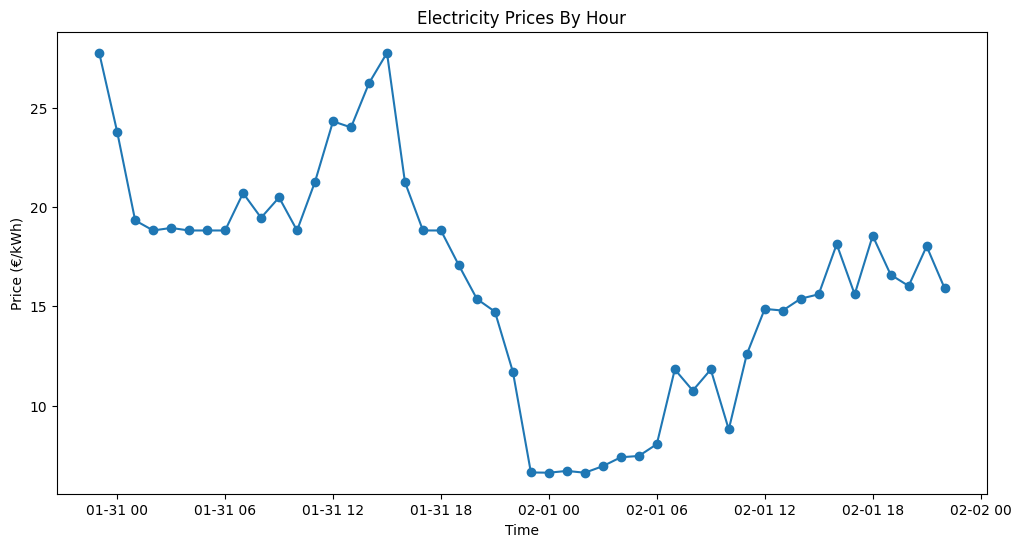

In [188]:

# change timestamp to to datetime
df['startDate'] = pd.to_datetime(df['startDate'])

# plot prices over time
df = df.sort_values('startDate')
plt.figure(figsize=(12, 6))
plt.plot(df['startDate'], df['price'], marker='o')
plt.title('Electricity Prices By Hour')
plt.xlabel('Time')
plt.ylabel('Price (€/kWh)')
plt.show()

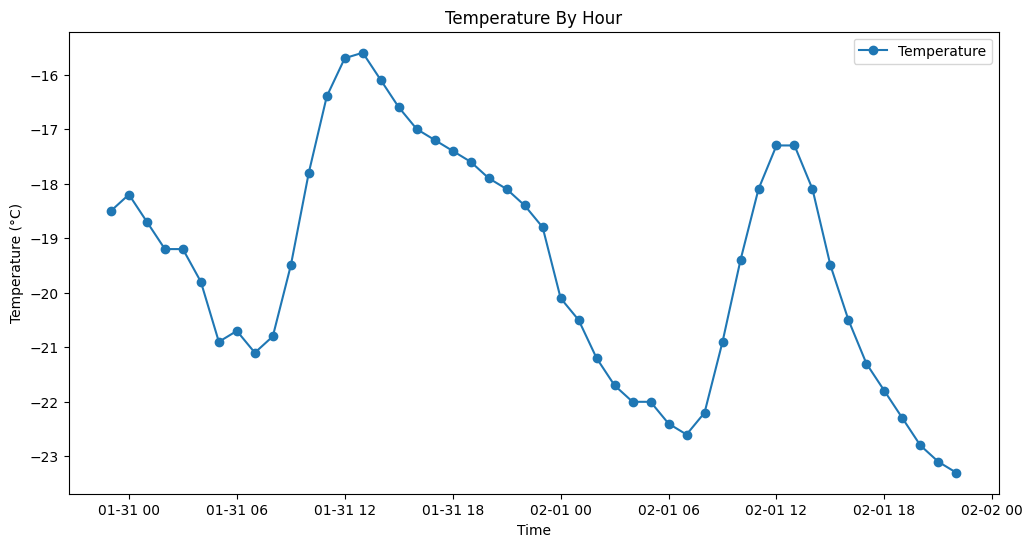

In [189]:
# plot prices over time
df = df.sort_values('time')
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['temp'], marker='o', label='Temperature')
plt.title('Temperature By Hour')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

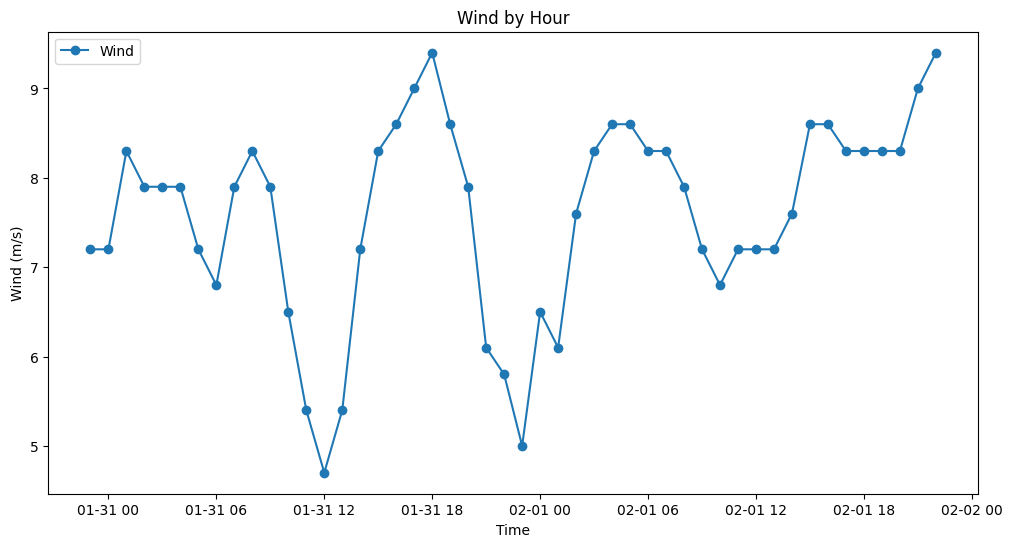

In [190]:
# plot prices over time
df = df.sort_values('time')
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['wind'], marker='o', label='Wind')
plt.title('Wind by Hour')
plt.xlabel('Time')
plt.ylabel('Wind (m/s)')
plt.legend()
plt.show()

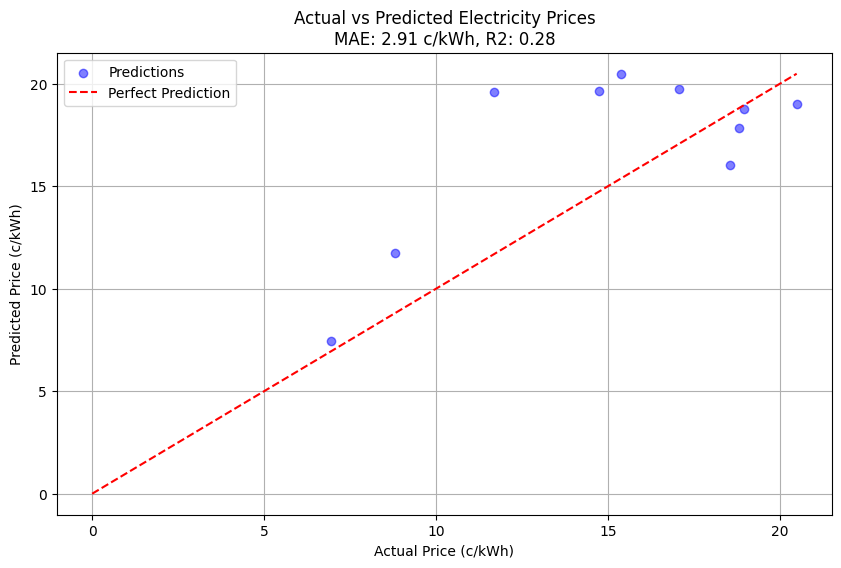

In [191]:
plt.figure(figsize=(10, 6))

# Piirretään todelliset vs ennustetut (pistekuvio)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')

# Piirretään "täydellisen ennusteen" viiva (diagonaali)
# Jos ennuste on täydellinen, pisteet osuvat tälle viivalle
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (c/kWh)')
plt.ylabel('Predicted Price (c/kWh)')
plt.title(f'Actual vs Predicted Electricity Prices\nMAE: {mae:.2f} c/kWh, R2: {r2:.2f}')
plt.legend()
plt.grid(True)